# 📈 Fintech Review Visualizations
This notebook generates premium plots using Matplotlib and Seaborn to analyze sentiment, ratings, keywords, and trends for CBE, Dashen, and BOA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import os

# Set plotting style for premium look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# Ensure directories exist
os.makedirs('plots', exist_ok=True)

In [2]:
# Load the clean reviews
df = pd.read_csv('data/processed/cleaned_bank_reviews.csv')

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Download VADER
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

def get_vader_score_and_label(text):
    if not isinstance(text, str):
        return 0.0, 'Neutral'
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        label = 'Positive'
    elif score <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return score, label

res = df['review'].apply(get_vader_score_and_label)
df['sentiment_score'] = [r[0] for r in res]
df['sentiment_label'] = [r[1] for r in res]

print(f"Data loaded: {len(df)} rows")
print(df.groupby(['app', 'sentiment_label']).size().unstack(fill_value=0))

Data loaded: 1458 rows
sentiment_label  Negative  Neutral  Positive
app                                         
BOA                    87      150       255
CBE                    54      114       309
Dashen                 63      112       314


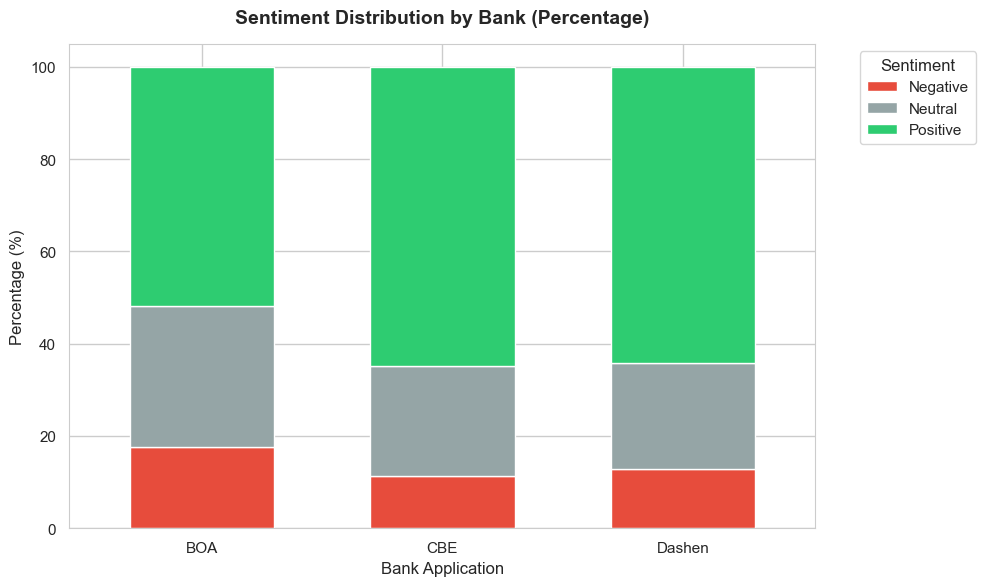

In [3]:
# Colors: Sleek red/grey/green
colors = {'Negative': '#E74C3C', 'Neutral': '#95A5A6', 'Positive': '#2ECC71'}

# Pivot data
sent_counts = df.groupby(['app', 'sentiment_label']).size().unstack(fill_value=0)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100

ax = sent_pct.plot(kind='bar', stacked=True, color=[colors[c] for c in sent_pct.columns], width=0.6)
plt.title('Sentiment Distribution by Bank (Percentage)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Application', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/sentiment_distribution.png', dpi=300)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_7164\2018736388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='app', y='rating', data=df, palette='Blues', width=0.5,


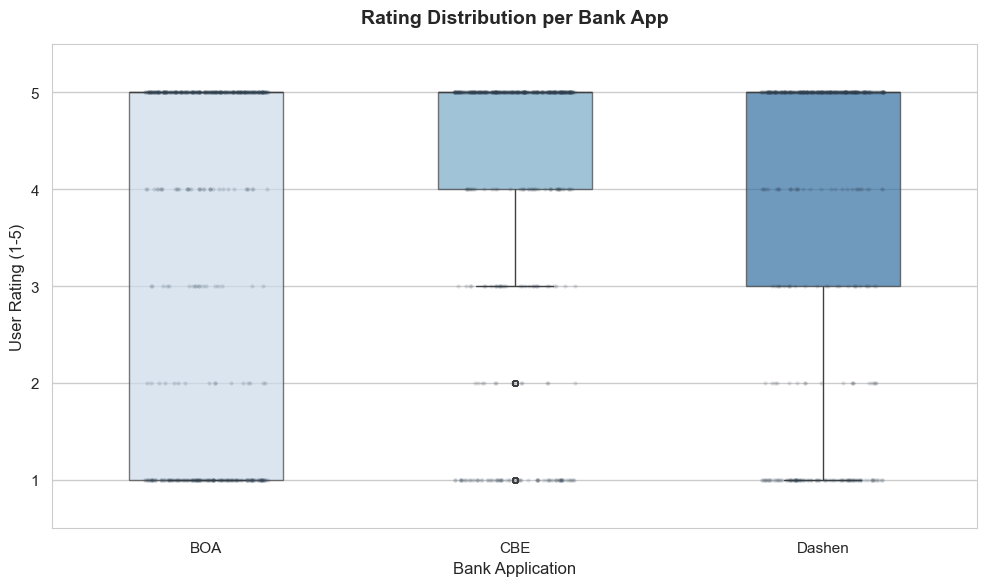

In [4]:
# Using a beautiful box plot with data strip overlay
plt.figure(figsize=(10, 6))
sns.boxplot(x='app', y='rating', data=df, palette='Blues', width=0.5, 
            boxprops=dict(alpha=0.7), flierprops=dict(marker='o', color='#E74C3C', markersize=4))
sns.stripplot(x='app', y='rating', data=df, color='#2C3E50', alpha=0.15, jitter=0.2, size=3)

plt.title('Rating Distribution per Bank App', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Application', fontsize=12)
plt.ylabel('User Rating (1-5)', fontsize=12)
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.savefig('plots/rating_distribution.png', dpi=300)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_7164\2253330206.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), ax=axes[i], palette='viridis')
C:\Users\PC\AppData\Local\Temp\ipykernel_7164\2253330206.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), ax=axes[i], palette='viridis')
C:\Users\PC\AppData\Local\Temp\ipykernel_7164\2253330206.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), ax=axes[i], palette='viridis')


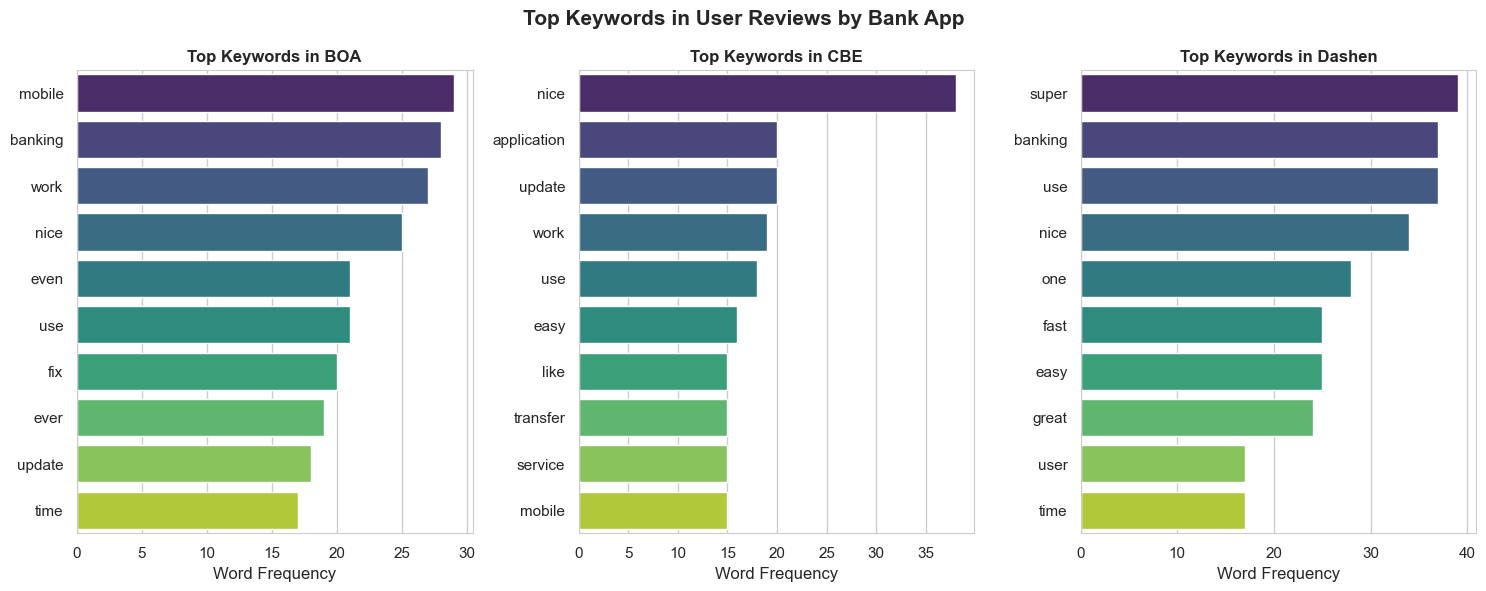

In [5]:
# Helper to extract clean keywords
from collections import Counter
from nltk.corpus import stopwords
import re

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
stop_words.update({'app', 'bank', 'cbe', 'boa', 'dashen', 'good', 'worst', 'bad', 'best', 'working', 'please'})

def clean_and_tokenize(text):
    if not isinstance(text, str):
        return []
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [w for w in words if w not in stop_words]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=False)
apps = df['app'].unique()

for i, app in enumerate(apps):
    app_reviews = df[df['app'] == app]['review']
    all_words = []
    for r in app_reviews:
        all_words.extend(clean_and_tokenize(r))
        
    counts = Counter(all_words).most_common(10)
    if counts:
        words, freqs = zip(*counts)
    else:
        words, freqs = [], []
        
    sns.barplot(x=list(freqs), y=list(words), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Keywords in {app}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Word Frequency')
    
plt.suptitle('Top Keywords in User Reviews by Bank App', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('plots/top_keywords.png', dpi=300)
plt.show()

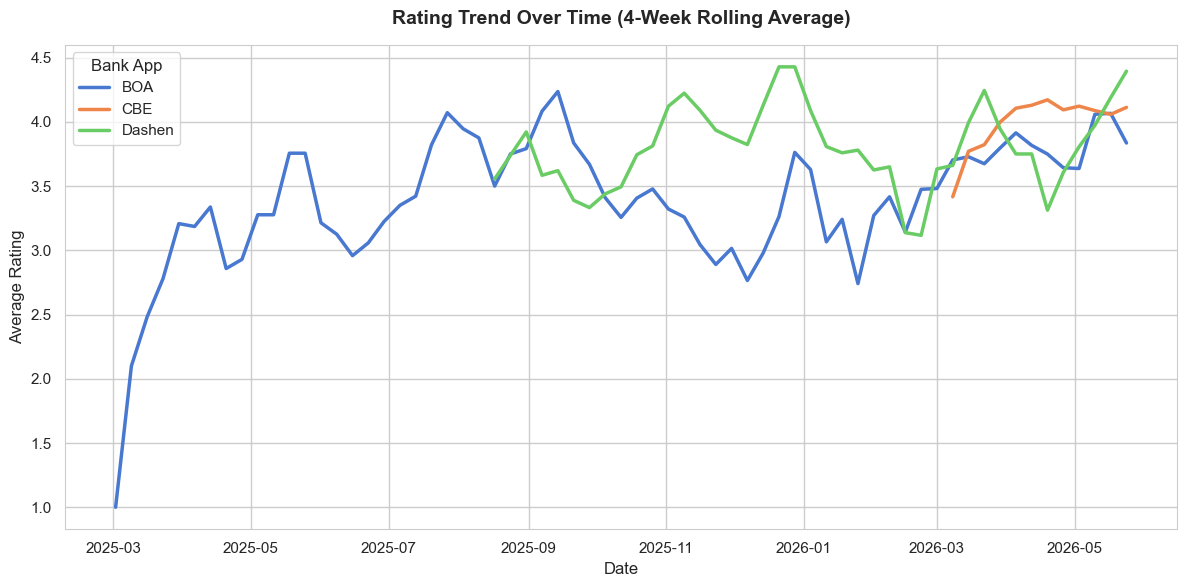

In [6]:
# Group by date and calculate rolling average
plt.figure(figsize=(12, 6))

for app in df['app'].unique():
    df_app = df[df['app'] == app].sort_values('date')
    df_trend = df_app.set_index('date').resample('W')['rating'].mean().reset_index()
    df_trend['rolling_rating'] = df_trend['rating'].rolling(window=4, min_periods=1).mean()
    
    plt.plot(df_trend['date'], df_trend['rolling_rating'], label=app, linewidth=2.5)

plt.title('Rating Trend Over Time (4-Week Rolling Average)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.legend(title='Bank App')
plt.tight_layout()
plt.savefig('plots/rating_trend_over_time.png', dpi=300)
plt.show()